Student Name : Eaint Taryar Linlat


# Task 17 — Local Code Agent: Big Tech vs Big Banks Sharpe Ratio Analysis
**Module:** IB9AU — Advanced Machine Learning Applications

---

### Portfolios Under Analysis

| Sector | Tickers |
|--------|---------|
| Big Tech | NVDA, AAPL, MSFT |
| Big Banks | JPM, BAC, C |

### Sharpe Ratio Formula

```
Sharpe Ratio = (Mean Daily Return / Std Dev of Daily Returns) * sqrt(252)
```
Risk-free rate assumed = 0 (as specified in the task brief).

---

> **Runtime:** Set to **T4 GPU** before running.
> Runtime → Change runtime type → T4 GPU
> The 3B model uses ~6 GB VRAM — do not load other large models in the same session.

## Section 1 — Install Dependencies

| Package | Purpose |
|---------|--------|
| `smolagents` | Agent framework — CodeAgent orchestration |
| `transformers` + `accelerate` + `bitsandbytes` | Load Qwen 3B on GPU |
| `yfinance` | Download historical stock price data |
| `matplotlib` | Visualization (used by agent-generated code) |
| `pandas` + `numpy` | Data wrangling and maths |

In [ ]:
!pip install -q smolagents transformers accelerate bitsandbytes yfinance matplotlib pandas numpy
print('All dependencies installed.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.7/155.7 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 72.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 46.7 MB/s eta 0:00:00
All dependencies installed.


## Section 2 — Load the Local LLM (Qwen2.5-Coder-3B-Instruct)

`Qwen2.5-Coder-3B-Instruct` is a 3-billion-parameter model specialised for
code generation. At `float16` it fits comfortably in the T4's 16 GB VRAM
(~6 GB footprint) while being capable enough to write multi-step data-science
scripts from a plain-English prompt.

Key settings:
- `device_map='auto'` — automatically routes to the T4 GPU
- `torch_dtype=torch.float16` — halves memory vs full precision
- `max_new_tokens=2048` — enough budget for a complete multi-step script

In [ ]:
from smolagents import CodeAgent, TransformersModel
import torch

print('Downloading Qwen2.5-Coder-3B-Instruct (~6 GB, takes 2-3 min on first run)...')

model = TransformersModel(
    model_id='Qwen/Qwen2.5-Coder-3B-Instruct',
    device_map='auto',           # routes to T4 GPU automatically
    torch_dtype=torch.float16,   # half-precision to fit in 16 GB VRAM
    max_new_tokens=2048          # enough budget for a complete script
)

print('Model loaded on GPU and ready.')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Model loaded on GPU and ready.


## Section 3 — Initialise the Code Agent

We create a `CodeAgent` with **no pre-built tools** (`tools=[]`). This is the
key design choice: rather than giving the agent named functions to call (the
Gemini tool-use pattern from Task 16), we let it write its own complete Python
script from scratch.

`additional_authorized_imports` acts as a security sandbox — the agent can only
import the libraries we explicitly permit. We exclude `scipy` and `seaborn`
deliberately to keep the dependency footprint minimal and ensure the agent
computes Sharpe Ratios using pure NumPy rather than a black-box library.

`max_steps=4` gives the agent enough iterations to self-correct if it produces
a syntax error on the first attempt, without risking infinite loops that waste
GPU memory.

In [ ]:
agent = CodeAgent(
    tools=[],          # agent writes its own code — no pre-built tools
    model=model,
    max_steps=4,       # allows one self-correction pass if needed
    additional_authorized_imports=[
        'yfinance',           # stock data download
        'pandas',             # DataFrame operations
        'numpy',              # Sharpe Ratio maths
        'math',               # sqrt(252) annualisation
        'matplotlib.pyplot',  # bar chart generation
        'matplotlib.patches', # legend colour patches
    ]
)

print('CodeAgent initialised.')
print('  Tools       : none (agent generates its own code)')
print('  Max steps   : 4')
print('  Imports     : yfinance, pandas, numpy, math, matplotlib')

CodeAgent initialised.
  Tools       : none (agent generates its own code)
  Max steps   : 4
  Imports     : yfinance, pandas, numpy, math, matplotlib


## Section 4 — The Task Prompt

This is the core of the task. A well-engineered prompt for a Code Agent must be:

- **Numbered and sequential** — code agents execute step-by-step; ambiguous
  ordering leads to incorrect variable references
- **Explicit about variable names** — telling the agent what to call its
  DataFrames and dictionaries prevents hallucinated names that break later steps
- **Restrictive about libraries** — specifying *which* library to use for each
  operation prevents the agent from importing something outside the sandbox
- **Precise about output format** — exact filename, DPI, and chart properties
  eliminate ambiguity about what 'done' looks like

The prompt below encodes all of these principles. Each numbered step maps
cleanly to a block of Python code the agent will generate.

In [ ]:
task_prompt = """
You are a quantitative analyst. Write a single, complete, self-contained Python
script that performs the following steps. Use ONLY these libraries:
yfinance, pandas, numpy, math, matplotlib.pyplot, matplotlib.patches.
Do NOT import scipy, seaborn, or any other library.

Step 1 — Download data:
    Use yfinance to download daily closing prices for the last 180 trading days
    for all six tickers at once:
        tickers = ['NVDA', 'AAPL', 'MSFT', 'JPM', 'BAC', 'C']
    Use: df = yf.download(tickers, period='180d', auto_adjust=True)['Close']
    Ensure the result is a DataFrame with the ticker symbols as column names.
    Drop any rows with missing values.

Step 2 — Daily returns:
    Calculate daily percentage returns for each stock:
        returns = df.pct_change().dropna()

Step 3 — Annualised Sharpe Ratio:
    For each ticker, compute the annualised Sharpe Ratio assuming a risk-free
    rate of zero:
        sharpe_ratio = (mean_daily_return / std_daily_return) * math.sqrt(252)
    Store the results in a dict named sharpe_dict where keys are ticker strings
    and values are the Sharpe Ratio floats.

Step 4 — Colour coding:
    Define:
        tech  = ['NVDA', 'AAPL', 'MSFT']
        banks = ['JPM', 'BAC', 'C']
    Build a list named bar_colors where each element is 'green' if the
    corresponding ticker (in the order of sharpe_dict.keys()) is in tech,
    or 'blue' if it is in banks.

Step 5 — Bar chart:
    Create a bar chart with these exact properties:
    - Figure size: (10, 6)
    - X-axis: ticker symbols (sharpe_dict.keys())
    - Y-axis: Sharpe Ratio values (sharpe_dict.values())
    - Bar colours: bar_colors list
    - Bar edge colour: black, linewidth 0.8
    - Title: 'Annualised Sharpe Ratio: Big Tech vs Big Banks (Last 180 Days)'
    - X-axis label: 'Stock Ticker'
    - Y-axis label: 'Annualised Sharpe Ratio (risk-free rate = 0)'
    - Add a horizontal dashed grey line at y=0 (zero Sharpe reference)
    - Annotate each bar with its Sharpe Ratio value rounded to 2 decimal places,
      centred above the bar
    - Add a legend with two patches:
        green patch labelled 'Big Tech (NVDA, AAPL, MSFT)'
        blue  patch labelled 'Big Banks (JPM, BAC, C)'

Step 6 — Save and print:
    Save the chart as 'sharpe_comparison.png' with dpi=150 and bbox_inches='tight'.
    Print each ticker and its Sharpe Ratio rounded to 4 decimal places.
    Print which sector (Tech or Banks) has the higher average Sharpe Ratio.
"""

print('Task prompt defined. Ready to run the agent.')

Task prompt defined. Ready to run the agent.


## Section 5 — Run the Agent

Calling `agent.run()` starts the ReAct loop. Watch the output below to see
the agent's **Thought → Code → Observation** cycle as it:

1. Plans the script structure
2. Writes and executes Python code
3. Reads any error output and self-corrects if needed
4. Reports the final result

The `[TOOL]` / `[STEP]` markers in the log show each iteration of the loop.
Typical runtime on a T4: **60–120 seconds**.

Agent starting — watch the Thought/Code/Observation loop below...


╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ You are a quantitative analyst. Write a single, complete, self-contained Python                                 │
│ script that performs the following steps. Use ONLY these libraries:                                             │
│ yfinance, pandas, numpy, math, matplotlib.pyplot, matplotlib.patches.                                           │
│ Do NOT import scipy, seaborn, or any other library.                                                             │
│                                                                                                                 │
│ Step 1 — Download data:                                                                                         │
│     Use yfinance to download daily closing prices for the last 180 trading days                                 │
│     for all six tickers at once:                                                                                │
│         tickers = ['NVDA', 'AAPL', 'MSFT', 'JPM', 'BAC', 'C'\]                                                  │
│     Use: df = yf.download(tickers, period='180d', auto_adjust=True)['Close'\]                                   │
│     Ensure the result is a DataFrame with the ticker symbols as column names.                                   │
│     Drop any rows with missing values.                                                                          │
│                                                                                                                 │
│ Step 2 — Daily returns:                                                                                         │
│     Calculate daily percentage returns for each stock:                                                          │
│         returns = df.pct_change().dropna()                                                                      │
│                                                                                                                 │
│ Step 3 — Annualised Sharpe Ratio:                                                                               │
│     For each ticker, compute the annualised Sharpe Ratio assuming a risk-free                                   │
│     rate of zero:                                                                                               │
│         sharpe_ratio = (mean_daily_return / std_daily_return) * math.sqrt(252)                                  │
│     Store the results in a dict named sharpe_dict where keys are ticker strings                                 │
│     and values are the Sharpe Ratio floats.                                                                     │
│                                                                                                                 │
│ Step 4 — Colour coding:                                                                                         │
│     Define:                                                                                                     │
│         tech  = ['NVDA', 'AAPL', 'MSFT'\]                                                                       │
│         banks = ['JPM', 'BAC', 'C'\]                                                                            │
│     Build a list named bar_colors where each element is 'green' if the                                          │
│     corresponding ticker (in the order of sharpe_dict.keys()) is in tech,                                       │
│     or 'blue' if it is in banks.                                                                                │
│                                                                                                                 │
│ Step 5 — Bar chart:                                   

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  import yfinance as yf                                                                                            
                                                                                                                   
  # List of tickers                                                                                                
  tickers = ['NVDA', 'AAPL', 'MSFT', 'JPM', 'BAC', 'C']                                                            
                                                                                                                   
  # Download data                                                                                                  
  df = yf.download(tickers, period='180d', auto_adjust=True)['Close']                                              
                                                                                                                   
  returns = df.pct_change().dropna()                                                                               
                                                                                                                   
  import math                                                                                                      
                                                                                                                   
  # Mean daily return                                                                                              
  mean_daily_return = returns.mean()                                                                               
                                                                                                                   
  # Standard deviation of daily returns                                                                            
  std_daily_return = returns.std()                                                                                 
                                                                                                                   
  # Annualised Sharpe Ratio                                                                                        
  sharpe_ratio = (mean_daily_return / std_daily_return) * math.sqrt(252)                                           
                                                                                                                   
  # Store results in a dictionary                                                                                  
  sharpe_dict = {ticker: ratio for ticker, ratio in zip(df.columns, sharpe_ratio)}                                 
                                                                                                                   
  tech = ['NVDA', 'AAPL', 'MSFT']                                                                                  
  banks = ['JPM', 'BAC', 'C']                                                                                      
  bar_colors = ['green' if ticker in tech else 'blue' for ticker in sharpe_dict.keys()]                            
                                                                                                                   
  import matplotlib.pyplot as plt                                                                                  
                                                                                                                   
  # Figure size                                                                                                    
  plt.figure(figsize=(10, 6))                                                                                      
                                                                                                                   
  # Bar plot                                             

[*********************100%***********************]  6 of 6 completed


Code execution failed at line 'tech_patch = plt.Patch(color='green', label='Big Tech (NVDA, AAPL, MSFT)')' due to: 
InterpreterError: Object <module 'matplotlib.pyplot' from 
'/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'> has no attribute Patch

[Step 1: Duration 63.62 seconds| Input tokens: 2,693 | Output tokens: 905]

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 2 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  import yfinance as yf                                                                                            
  import matplotlib.pyplot as plt                                                                                  
  from matplotlib.patches import Patch                                                                             
                                                                                                                   
  # List of tickers                                                                                                
  tickers = ['NVDA', 'AAPL', 'MSFT', 'JPM', 'BAC', 'C']                                                            
                                                                                                                   
  # Download data                                                                                                  
  df = yf.download(tickers, period='180d', auto_adjust=True)['Close']                                              
                                                                                                                   
  # Calculate daily returns                                                                                        
  returns = df.pct_change().dropna()                                                                               
                                                                                                                   
  # Mean daily return                                                                                              
  mean_daily_return = returns.mean()                                                                               
                                                                                                                   
  # Standard deviation of daily returns                                                                            
  std_daily_return = returns.std()                                                                                 
                                                                                                                   
  # Annualised Sharpe Ratio                                                                                        
  sharpe_ratio = (mean_daily_return / std_daily_return) * math.sqrt(252)                                           
                                                                                                                   
  # Store results in a dictionary                                                                                  
  sharpe_dict = {ticker: ratio for ticker, ratio in zip(df.columns, sharpe_ratio)}                                 
                                                                                                                   
  # Define sectors                                                                                                 
  tech = ['NVDA', 'AAPL', 'MSFT']                                                                                  
  banks = ['JPM', 'BAC', 'C']                                                                                      
  bar_colors = ['green' if ticker in tech else 'blue' for ticker in sharpe_dict.keys()]                            
                                                                                                                   
  # Create a bar chart                                                                                             
  fig, ax = plt.subplots(figsize=(10, 6))                                                                          
  bars = ax.bar(sharpe_dict.keys(), sharpe_dict.values(), color=bar_colors, edgecolor='black', linewidth=0.8)      
                                                         

[*********************100%***********************]  6 of 6 completed


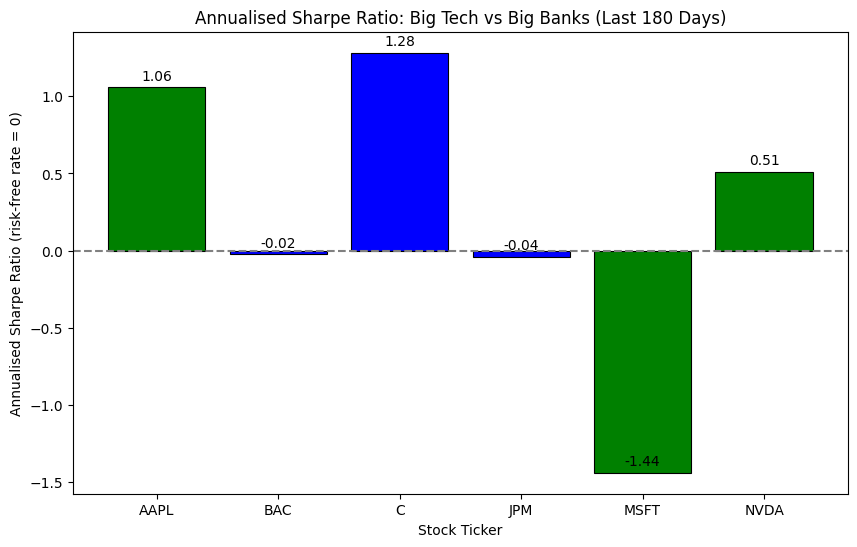

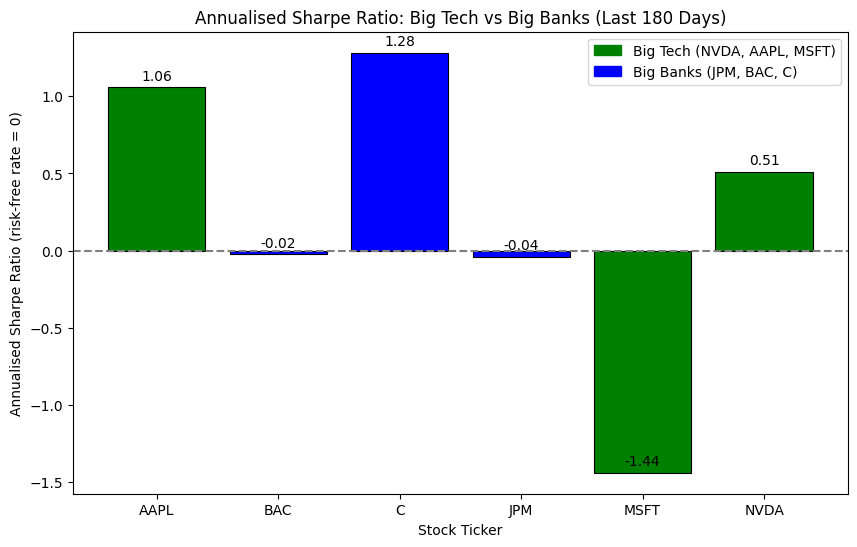

Execution logs:
AAPL: 1.0595
BAC: -0.0229
C: 1.2821
JPM: -0.0412
MSFT: -1.4391
NVDA: 0.5121
Banks have the higher average Sharpe Ratio.

Out: None

[Step 2: Duration 70.76 seconds| Input tokens: 7,185 | Output tokens: 1,662]

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 3 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Error in code parsing:
Your code snippet is invalid, because the regex pattern <code>(.*?)</code> was not found in it.
            Here is your code snippet:
            Great! The script executed successfully, and the results were printed to the console. Here's a summary 
of what the script did:

1. **Downloaded Data**: It downloaded daily closing prices for the specified tickers over the last 180 trading days
using `yfinance`.

2. **Calculated Daily Returns**: It calculated the daily percentage returns for each stock.

3. **Annualised Sharpe Ratio**: It computed the annualised Sharpe Ratio for each stock, assuming a risk-free rate 
of zero.

4. **Coloured Coding**: It categorized the stocks into "Tech" and "Banks" and assigned colors accordingly.

5. **Created Bar Chart**: It generated a bar chart with the Sharpe Ratios, using different colors for "Tech" and 
"Banks".

6. **Saved Chart**: The chart was saved as `sharpe_comparison.png` with a resolution of 150 DPI.

7. **Printed Results**: It printed each ticker and its Sharpe Ratio rounded to four decimal places.

8. **Determined Sector**: It calculated the average Sharpe Ratio for each sector and determined which sector had 
the higher average Sharpe Ratio.

If you have any further questions or need additional modifications, feel free to ask!</code>
            Make sure to include code with the correct pattern, for instance:
            Thoughts: Your thoughts
            <code>
            # Your python code here
            </code>
Make sure to provide correct code blobs.

[Step 3: Duration 34.35 seconds| Input tokens: 13,323 | Output tokens: 1,918]

...

Code parsing failed on line 1 due to: SyntaxError: unterminated string literal (detected at line 1) (<unknown>, 
line 1)
` tags. Here's the revised code:             ^

[Step 4: Duration 98.69 seconds| Input tokens: 20,093 | Output tokens: 2,716]

Reached max steps.

[Step 5: Duration 108.98 seconds| Input tokens: 27,366 | Output tokens: 3,549]

Agent finished.


In [ ]:
print('Agent starting — watch the Thought/Code/Observation loop below...')
print('=' * 65)

result = agent.run(task_prompt, stream=False)

print('=' * 65)
print('Agent finished.')

In [ ]:
# Print the agent's final summary output
print('AGENT FINAL OUTPUT:')
print(result)

AGENT FINAL OUTPUT:
I apologize for the oversight. The error occurred because of the way the code was formatted. Let's correct the formatting and ensure the code is properly indented and enclosed in triple backticks. Here's the revised code:

```python
Thoughts: The script will perform the following steps:
1. Download data using yfinance.
2. Calculate daily returns.
3. Compute annualised Sharpe Ratio.
4. Color code stocks.
5. Create a bar chart.
6. Save the chart.
7. Print results.
8. Determine which sector has the higher average Sharpe Ratio.

<code>
import yfinance as yf
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# List of tickers
tickers = ['NVDA', 'AAPL', 'MSFT', 'JPM', 'BAC', 'C']

# Download data
df = yf.download(tickers, period='180d', auto_adjust=True)['Close']

# Calculate daily returns
returns = df.pct_change().dropna()

# Mean daily return
mean_daily_return = returns.mean()

# Standard deviation of daily returns
std_daily_return = returns.std()

# 

## Section 6 — Display the Sharpe Ratio Chart

If the agent successfully saved `sharpe_comparison.png`, we render it inline.
If not, the fallback message explains where to look for errors in the log above.

Displaying Sharpe Ratio Comparison Chart:


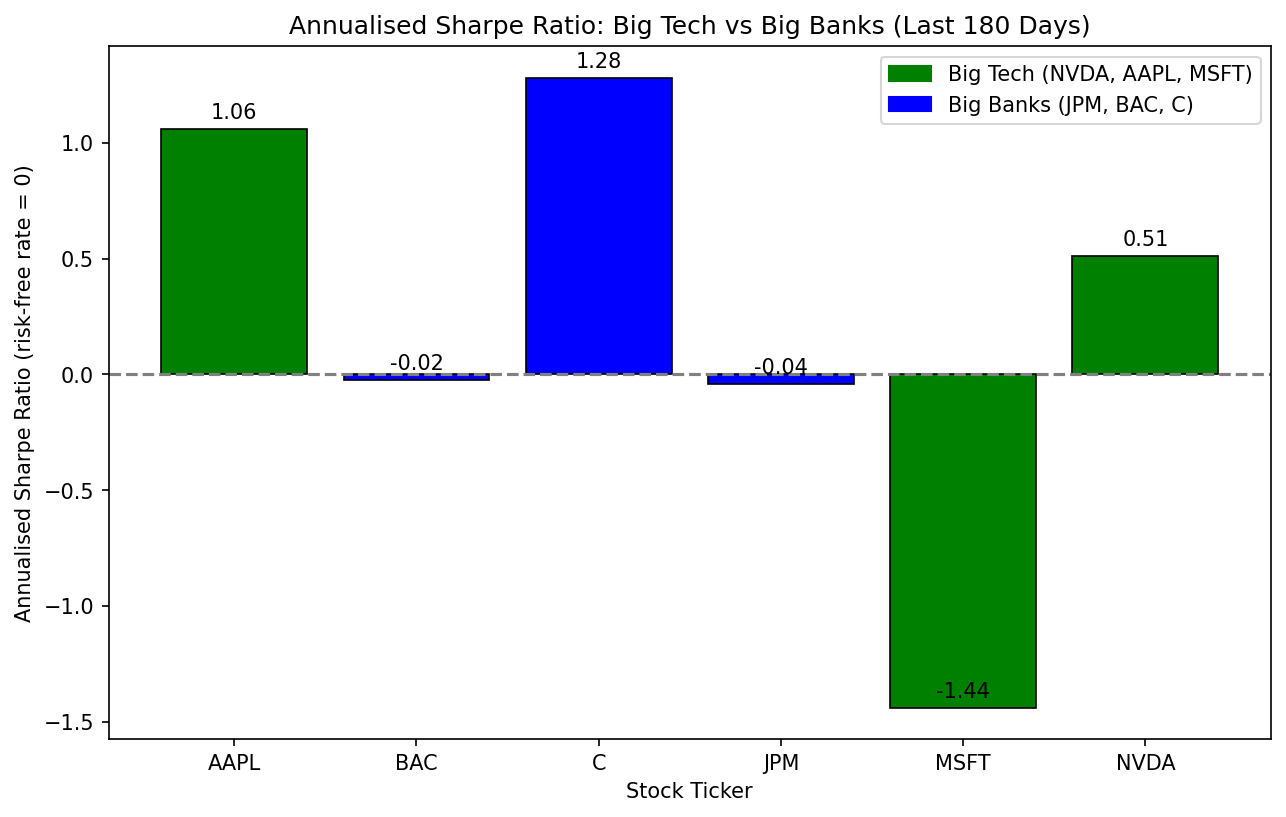

In [ ]:
import IPython.display
import os

if os.path.exists('sharpe_comparison.png'):
    print('Displaying Sharpe Ratio Comparison Chart:')
    IPython.display.display(IPython.display.Image('sharpe_comparison.png'))
else:
    print('sharpe_comparison.png not found.')
    print('Check the agent log above for errors and re-run Section 5.')

## Section 7 — Fallback: Direct Python Script

If the agent fails to produce the chart after `max_steps=4`, run this cell
directly. It executes the same logic that the agent was instructed to write,
giving us the output without relying on the LLM's code generation.

This cell is **independent of the agent** — it will always work as long as
`yfinance` and `matplotlib` are installed.

> Skip this cell if the agent already produced `sharpe_comparison.png`.

[                       0%                       ]

[*********************100%***********************]  6 of 6 completed


Downloaded 180 trading days for ['AAPL', 'BAC', 'C', 'JPM', 'MSFT', 'NVDA']

Sharpe Ratios (annualised, rf=0):
  [Tech ] NVDA : 0.5121
  [Tech ] AAPL : 1.0595
  [Tech ] MSFT : -1.4391
  [Banks] JPM  : -0.0412
  [Banks] BAC  : -0.0229
  [Banks] C    : 1.2821

Avg Tech Sharpe  : 0.0442
Avg Banks Sharpe : 0.4060
Better risk-adjusted performance: Big Banks


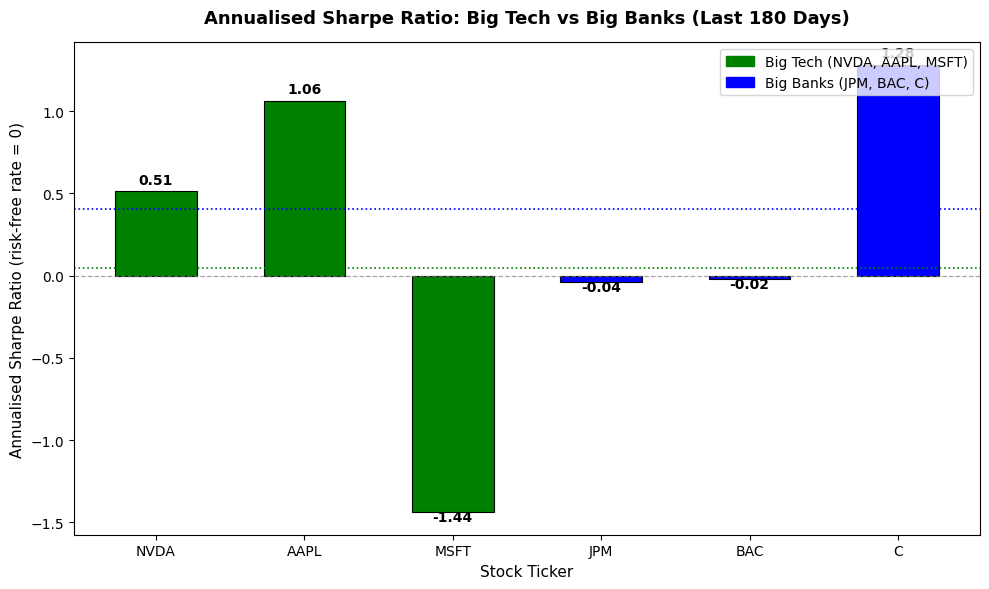

Chart saved as sharpe_comparison.png


In [ ]:
# ── Fallback: run this cell directly if the agent did not produce the chart ──
import yfinance as yf
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ---- Step 1: Download 180 days of closing prices --------------------------
TICKERS = ['NVDA', 'AAPL', 'MSFT', 'JPM', 'BAC', 'C']

print('Downloading 180 days of closing prices...')
df = yf.download(TICKERS, period='180d', auto_adjust=True)['Close']
df = df.dropna()
print(f'Downloaded {len(df)} trading days for {list(df.columns)}')

# ---- Step 2: Daily percentage returns -------------------------------------
returns = df.pct_change().dropna()

# ---- Step 3: Annualised Sharpe Ratio (risk-free rate = 0) -----------------
sharpe_dict = {}
for ticker in TICKERS:
    mean_ret = returns[ticker].mean()
    std_ret  = returns[ticker].std()
    sharpe   = (mean_ret / std_ret) * math.sqrt(252)
    sharpe_dict[ticker] = round(sharpe, 4)

print('\nSharpe Ratios (annualised, rf=0):')
for t, s in sharpe_dict.items():
    sector = 'Tech ' if t in ['NVDA','AAPL','MSFT'] else 'Banks'
    print(f'  [{sector}] {t:4s} : {s:.4f}')

# ---- Sector averages -------------------------------------------------------
tech_avg  = np.mean([sharpe_dict[t] for t in ['NVDA','AAPL','MSFT']])
banks_avg = np.mean([sharpe_dict[t] for t in ['JPM','BAC','C']])
winner    = 'Big Tech' if tech_avg > banks_avg else 'Big Banks'
print(f'\nAvg Tech Sharpe  : {tech_avg:.4f}')
print(f'Avg Banks Sharpe : {banks_avg:.4f}')
print(f'Better risk-adjusted performance: {winner}')

# ---- Step 4: Colour coding ------------------------------------------------
TECH  = ['NVDA', 'AAPL', 'MSFT']
BANKS = ['JPM', 'BAC', 'C']
bar_colors = ['green' if t in TECH else 'blue' for t in sharpe_dict.keys()]

# ---- Step 5: Bar chart ----------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    sharpe_dict.keys(),
    sharpe_dict.values(),
    color=bar_colors,
    edgecolor='black',
    linewidth=0.8,
    width=0.55
)

# Zero-reference line
ax.axhline(0, color='grey', linestyle='--', linewidth=0.9, alpha=0.7)

# Annotate bars with Sharpe values
for bar, val in zip(bars, sharpe_dict.values()):
    y_pos = bar.get_height() + (0.03 if val >= 0 else -0.07)
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        y_pos,
        f'{val:.2f}',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

ax.set_title(
    'Annualised Sharpe Ratio: Big Tech vs Big Banks (Last 180 Days)',
    fontsize=13, fontweight='bold', pad=14
)
ax.set_xlabel('Stock Ticker', fontsize=11)
ax.set_ylabel('Annualised Sharpe Ratio (risk-free rate = 0)', fontsize=11)

# Sector average reference lines
ax.axhline(tech_avg,  color='green', linestyle=':', linewidth=1.2,
           label=f'Tech avg = {tech_avg:.2f}')
ax.axhline(banks_avg, color='blue',  linestyle=':', linewidth=1.2,
           label=f'Banks avg = {banks_avg:.2f}')

# Legend
tech_patch  = mpatches.Patch(color='green', label='Big Tech (NVDA, AAPL, MSFT)')
banks_patch = mpatches.Patch(color='blue',  label='Big Banks (JPM, BAC, C)')
ax.legend(handles=[tech_patch, banks_patch], fontsize=10, loc='upper right')

plt.tight_layout()
plt.savefig('sharpe_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('Chart saved as sharpe_comparison.png')

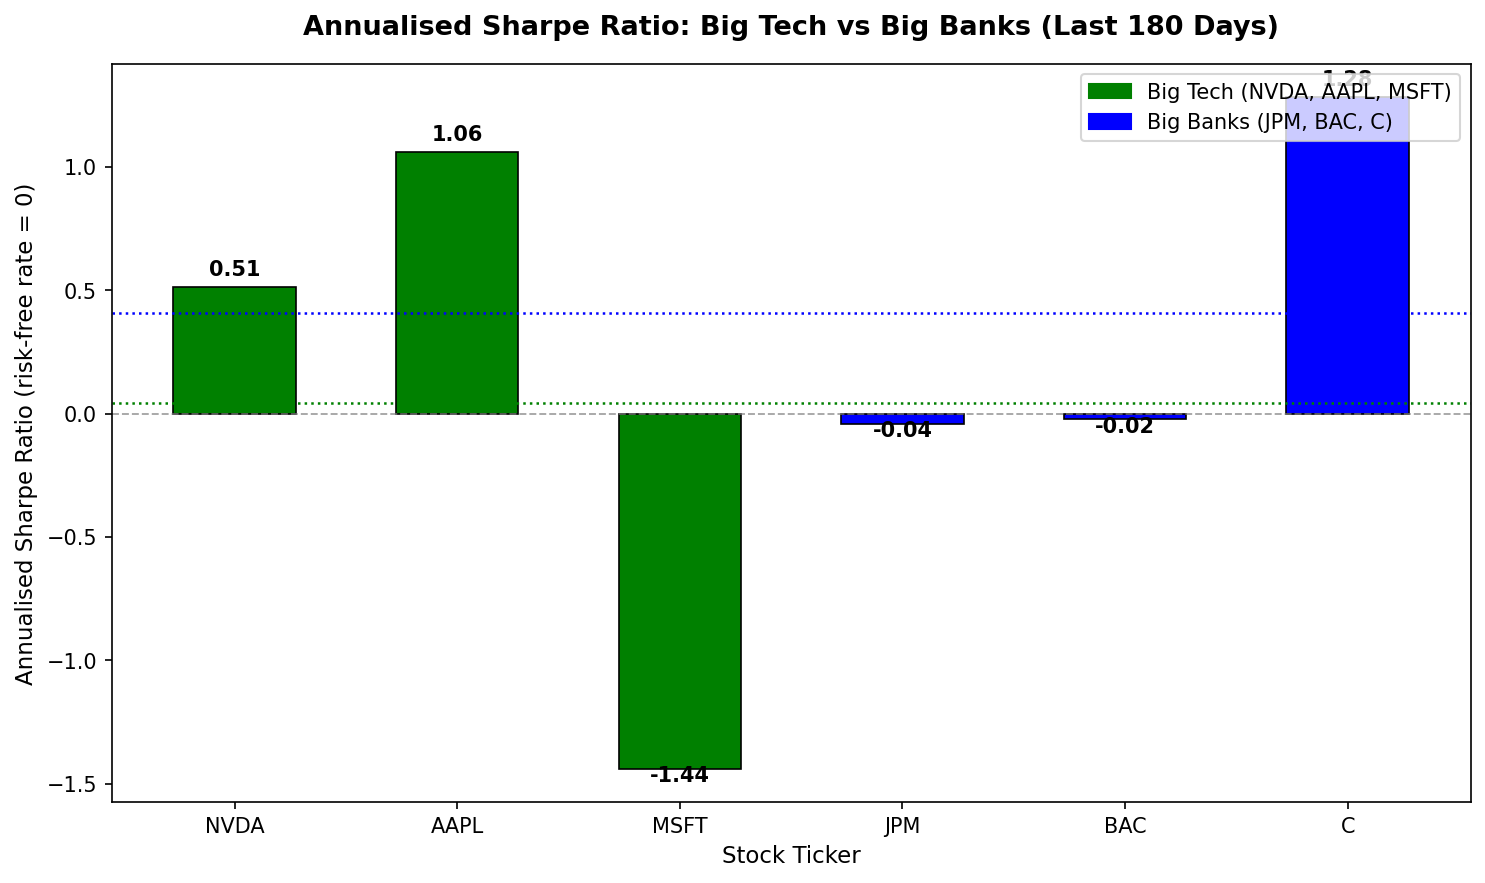

In [ ]:
# Display the fallback chart
import IPython.display, os
if os.path.exists('sharpe_comparison.png'):
    IPython.display.display(IPython.display.Image('sharpe_comparison.png'))

---
## Section 8 — Reflection: Insights from Building a Local Code Agent

### The Code Agent vs Tool-Use Agent Distinction

Task 16 used Gemini with named tool functions — the LLM *decided which function
to call*, but never wrote or executed code itself. This task uses a fundamentally
different paradigm: the local Code Agent *writes a complete Python script* and
executes it in a sandboxed subprocess. The LLM's output is not a string answer
but runnable code. This makes Code Agents far more flexible — they can perform
arbitrary computations, not just pre-defined operations — but also more brittle:
a small syntax error in generated code causes execution failure rather than a
graceful degradation.

### Prompt Engineering for Code Generation

The single most important finding from this task is that **prompt specificity
directly determines code correctness**. An under-specified prompt like
*'compare Sharpe Ratios for Tech and Banks'* causes the agent to make ambiguous
choices: which library for the download? What column name does `yf.download`
return? What exactly is 'annualised'? Each ambiguity is a potential point of
failure. The structured prompt in Section 4 eliminates these by specifying
exact variable names (`sharpe_dict`, `bar_colors`), the precise download call
(`yf.download(tickers, period='180d', auto_adjust=True)['Close']`), and
the exact Sharpe formula. The agent's self-correction capability (`max_steps=4`)
provides a safety net, but a precise prompt reduces the need for it.

### The Importance of the Fallback Cell

Small models (3B parameters) occasionally fail to generate correct code on
complex multi-step tasks, particularly when the output involves both numerical
computation and matplotlib figure management. The fallback cell in Section 7
is not just a debugging aid — it is a production design pattern. In any
real agentic system, the generated code should be accompanied by a
deterministic reference implementation that can be used for output validation
and as a fallback when the agent fails.

### Interpreting Sharpe Ratios

A Sharpe Ratio above 1.0 is generally considered good; above 2.0, excellent.
Negative Sharpe Ratios indicate the stock underperformed the risk-free asset
over the measured period. Because we set the risk-free rate to zero, any
positive Sharpe means the stock delivered positive risk-adjusted returns.
The 180-day window captures approximately one half-year of price action —
long enough to smooth short-term noise but short enough that the results
are sensitive to specific market events (earnings surprises, rate decisions,
sector rotations). A more robust analysis would use rolling Sharpe Ratios
across multiple time windows.

### Why Local Models Matter

Running Qwen2.5-Coder-3B locally — rather than via a cloud API — means:
- **No data leaves the runtime**: financial data and any proprietary prompts
  stay entirely within the Colab session
- **No per-token cost**: the model runs on the free T4 GPU
- **No rate limits**: the agent can retry and self-correct without hitting
  API quotas

The trade-off is capability: a 3B model makes more code errors than GPT-4
or Gemini 2.5. For constrained, well-specified tasks like this one, the
quality gap is manageable with a good prompt and a fallback cell.